# Setup

In [1]:
from PIL import Image
import json
import torch
import numpy as np
from tqdm.notebook import tqdm
import random

In [2]:
def get_device():
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device = get_device()


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
cd /content/drive/MyDrive/Gaussian_Splat/

/content/drive/MyDrive/Gaussian_Splat


## GaussianSplat2D Class

In [5]:
class GaussianSplat2D:
    def covariance_2d(scale, theta):
        sx = scale[:, 0]
        sy = scale[:, 1]

        c = torch.cos(theta)
        s = torch.sin(theta)

        sx2 = sx ** 2
        sy2 = sy ** 2
        c2 = c ** 2
        s2 = s ** 2
        cs = c * s

        sigma_xx = c2 * sx2 + s2 * sy2
        sigma_xy = cs * (sx2 - sy2)
        sigma_yy = s2 * sx2 + c2 * sy2

        return torch.stack([
            sigma_xx, sigma_xy,
            sigma_xy, sigma_yy
        ], dim=1).reshape(-1, 2, 2)

    def gaussian_weight(xy, mu, Sigma):
        diff = xy[:, None, :] - mu[None, :, :]
        Sigma_inv = torch.linalg.inv(Sigma)
        exponent = -0.5 * torch.einsum('pni,nij,pnj->pn', diff, Sigma_inv, diff)
        return torch.exp(exponent)

    def pixel_grid(H, W, device):
        y, x = torch.meshgrid(
            torch.arange(H, dtype=torch.float32, device=device) + 0.5,
            torch.arange(W, dtype=torch.float32, device=device) + 0.5,
            indexing='ij'
        )
        return torch.stack([x, y], dim=-1).reshape(-1, 2)

    def render(mu, Sigma, color, opacity, order, H, W):
        # color: (N, 3),  opacity: (N,) in [0, 1],  order: indices sorted front -> back

        y_range = torch.linspace(0, H-1, steps=H).to(device)  # Rows
        x_range = torch.linspace(0, W-1, steps=W).to(device)  # Columns

        # Create the mesh grid
        # Note: "ij" is the default behavior in newer PyTorch versions
        grid_y, grid_x = torch.meshgrid(y_range, x_range, indexing="ij")

        # Stack to get an (H, W, 2) grid of (y, x) coordinates
        grid_ij = torch.stack([grid_y, grid_x], dim=-1)

        xy = grid_ij.reshape(-1, 2).float()+0.5  # (H*W, 2)
        assert xy.shape == (H * W, 2)

        w  = GaussianSplat2D.gaussian_weight(xy, mu, Sigma)       # (P, N)  from P1
        alpha = opacity[None, :] * w              # (P, N)
        C = torch.zeros(H * W, 3).to(device)
        T = torch.ones(H * W).to(device)

        log_t = torch.log1p(-alpha.clamp(max=1-1e-6))
        T = torch.exp(torch.cumsum(log_t, dim=1)-log_t)
        C = (T * alpha) @ color[order]

        return C.reshape(H, W, 3)

    def render_tiled(mu, Sigma, color, opacity, order, H, W):
        tile_size = 64
        radius_scale = 3.0
        y_range = torch.linspace(0, H-1, steps=H).to(device)  # Rows
        x_range = torch.linspace(0, W-1, steps=W).to(device)  # Columns

        # Create the mesh grid
        # Note: "ij" is the default behavior in newer PyTorch versions
        grid_y, grid_x = torch.meshgrid(y_range, x_range, indexing="ij")

        # Stack to get an (H, W, 2) grid of (y, x) coordinates
        grid_ij = torch.stack([grid_y, grid_x], dim=-1)

        xy = grid_ij.reshape(-1, 2).float()+0.5  # (H*W, 2)
        xy = GaussianSplat2D.pixel_grid(H, W, device)
        xy = xy.reshape(H, W, 2)

        mu = mu[order]
        Sigma = Sigma[order]
        color = color[order]
        opacity = opacity[order]

        rx = radius_scale * torch.sqrt(Sigma[:, 0, 0])
        ry = radius_scale * torch.sqrt(Sigma[:, 1, 1])

        rows = []

        for y0 in range(0, H, tile_size):
            y1 = min(y0 + tile_size, H)
            row = []

            for x0 in range(0, W, tile_size):
                x1 = min(x0 + tile_size, W)

                tile_xy = xy[y0:y1, x0:x1].reshape(-1, 2)

                xmin = x0 + 0.5
                xmax = x1 - 0.5
                ymin = y0 + 0.5
                ymax = y1 - 0.5

                mask = (
                    (mu[:, 0] + rx >= xmin) &
                    (mu[:, 0] - rx <= xmax) &
                    (mu[:, 1] + ry >= ymin) &
                    (mu[:, 1] - ry <= ymax)
                )

                indices = torch.nonzero(mask, as_tuple=False).squeeze(1)

                if indices.numel() == 0:
                    tile = torch.zeros(
                        (y1 - y0) * (x1 - x0), 3,
                        device=mu.device
                    )
                else:
                    tile_mu = mu[indices]
                    tile_Sigma = Sigma[indices]
                    tile_color = color[indices]
                    tile_opacity = opacity[indices]

                    w = GaussianSplat2D.gaussian_weight(
                        tile_xy,
                        tile_mu,
                        tile_Sigma
                    )

                    a = tile_opacity[None, :] * w

                    T_before = torch.cumprod(
                        torch.cat([
                            torch.ones(
                                tile_xy.shape[0], 1,
                                device=mu.device
                            ),
                            1.0 - a
                        ], dim=1),
                        dim=1
                    )[:, :-1]

                    tile = (T_before * a) @ tile_color

                row.append(
                    tile.reshape(y1 - y0, x1 - x0, 3)
                )

            rows.append(torch.cat(row, dim=1))

        return torch.cat(rows, dim=0)

    def optimize2D(target, N, budget, tiled=True, densify=True):
        device = get_device()
        target = torch.from_numpy(np.array(target)).float().to(device) / 255.0
        H, W , _ = target.shape

        # parameters (leaf tensors, requires_grad=True); a spread-out init, e.g.:
        torch.manual_seed(23)
        mu     = (torch.rand(N, 2, device=device) * torch.tensor([W, H], device=device))                  # (N, 2)  spread across the image
        mu.requires_grad = True
        log_s  = torch.log(0.02 * max(H, W) * torch.ones(N, 2, device=device))             # (N, 2)  small blobs, log space
        log_s.requires_grad = True
        theta  = torch.zeros(N, requires_grad=True, device=device)                         # (N,)    rotation
        color  = torch.zeros(N, 3, requires_grad=True, device=device)                      # (N, 3)  sigmoid -> 0.5 gray
        op_raw = torch.full((N,), -2.0, requires_grad=True, device=device)                 # (N,)    sigmoid -> ~0.12 opacity

        densify_every  = 200          # run a pass every 200 optimization steps
        grad_mag = torch.zeros(N, device = device)

        opt = torch.optim.Adam([mu, log_s, theta, color, op_raw], lr=1e-2)
        depth_order = torch.arange(N, device=device)

        with tqdm(range(2000), desc="Processing items") as pbar:
            for step in pbar:
                Sigma = GaussianSplat2D.covariance_2d(log_s.exp(), theta)
                if tiled:
                    img = GaussianSplat2D.render_tiled(mu, Sigma, color.sigmoid(), op_raw.sigmoid(), depth_order, H, W)
                else:
                    img = GaussianSplat2D.render(
                        mu,
                        Sigma,
                        color.sigmoid(),
                        op_raw.sigmoid(),
                        depth_order,
                        H,
                        W
                    )
                loss = ((img - target) ** 2).mean()

                opt.zero_grad(set_to_none=True); loss.backward(); opt.step()

                with torch.no_grad():
                    log_s.clamp_(min=np.log(0.01), max=np.log(256.0))
                    psnr = -10 * torch.log10(loss)
                pbar.set_postfix(N=mu.shape[0], loss=loss.item(), psnr=psnr.item())
                # densification
                if (densify): grad_mag += torch.linalg.vector_norm(mu.grad, dim=1)
                if (densify and ((step + 1) % densify_every == 0)):
                    mu, log_s, theta, color, op_raw = GaussianSplat2D.densify((mu, log_s, theta, color, op_raw), grad_mag / densify_every, budget, W)
                    grad_mag = torch.zeros(mu.shape[0], device=mu.device)
                    depth_order = torch.arange(mu.shape[0], device=device)

                    mu = mu.detach().requires_grad_(True)
                    log_s = log_s.detach().requires_grad_(True)
                    theta = theta.detach().requires_grad_(True)
                    color = color.detach().requires_grad_(True)
                    op_raw = op_raw.detach().requires_grad_(True)
                    opt = torch.optim.Adam([mu, log_s, theta, color, op_raw], lr=1e-2)

        with torch.no_grad():
            Sigma = GaussianSplat2D.covariance_2d(log_s.exp(), theta)
            if tiled:
                img = GaussianSplat2D.render_tiled(mu, Sigma, color.sigmoid(), op_raw.sigmoid(), depth_order, H, W)
            else:
                img = GaussianSplat2D.render(mu, Sigma, color.sigmoid(), op_raw.sigmoid(),depth_order, H, W)

            final_loss = ((img - target) ** 2).mean()
            psnr = -10 * torch.log10(final_loss)

            print(f"Final PSNR: {psnr.item():.2f} dB")
            if (densify):
                print("with densification")
            else:
                print("without densification")

            img = (img.cpu().numpy() * 255).clip(0, 255).astype(np.uint8)

            print(f"Initial # Gaussians {N}, Final # Gaussians: {mu.shape[0]}")
            return img


    def clone(gaussians, i):
        mu, log_s, theta, color, op_raw = gaussians
        mu = torch.cat([mu, mu[i:i+1]], dim=0)
        log_s = torch.cat([log_s, log_s[i:i+1]], dim=0)
        theta = torch.cat([theta, theta[i:i+1]], dim=0)
        color = torch.cat([color, color[i:i+1]], dim=0)
        op_raw = torch.cat([op_raw, op_raw[i:i+1]], dim=0)
        return (mu, log_s, theta, color, op_raw)

    def split(gaussians, i, split_scale):
        mu, log_s, theta, color, op_raw = gaussians
        new_log_s = log_s.clone()
        new_log_s[i] = new_log_s[i] - torch.log(torch.tensor(split_scale, device=log_s.device))

        return GaussianSplat2D.clone((mu, new_log_s, theta, color, op_raw), i)


    # run inside the P3 training loop, every densify_every steps
    def densify(gaussians, grad_mag, budget, W):
        mu, log_s, theta, color, op_raw = gaussians
        count = mu.shape[0]
        max_count      = budget      # a target count N from P5 (e.g. 256, 1024, 4096)

        if (count >= max_count): return gaussians

        # grad_threshold = 2e-4         # densify Gaussian i if g_i > grad_threshold
        densify_percent = 0.15
        size_threshold = 0.02 * W        # clone if max scale <= 2% of image width, else split
        split_scale    = 1.6          # each split child gets (parent scale / split_scale)
        prune_opacity  = 0.005        # remove Gaussian i if its opacity < this



        #prune Gaussians with opacity < prune_opacity
        keep = op_raw.sigmoid() >= prune_opacity
        mu = mu[keep]
        log_s = log_s[keep]
        theta = theta[keep]
        color = color[keep]
        op_raw = op_raw[keep]
        grad_mag = grad_mag[keep]
        count = mu.shape[0]

        # grad_mag: per-Gaussian g_i accumulated since the last pass
        scale = log_s.exp()
        max_scale = scale.max(dim=1).values
        num_densify = max(1, int(densify_percent * count))

        clone = (max_scale <= size_threshold)  #(duplicate in place)
        clone_idx = torch.nonzero(clone).squeeze(1)
        split = (max_scale >  size_threshold)  #(2 children, scale / split_scale)
        split_idx = torch.nonzero(split).squeeze(1)

        changes = torch.cat([clone_idx, split_idx])

        is_split = torch.cat([
            torch.zeros(clone_idx.shape[0], dtype=torch.bool, device=mu.device),
            torch.ones(split_idx.shape[0], dtype=torch.bool, device=mu.device)
        ])

        order = torch.argsort(grad_mag[changes], descending=True)
        order = order[:num_densify]

        changes = changes[order]
        is_split = is_split[order]

        for i, split in zip(changes, is_split):
            if count >= max_count:
                break

            gaussians = (mu, log_s, theta, color, op_raw)
            if split:
                mu, log_s, theta, color, op_raw = GaussianSplat2D.split(gaussians, i, split_scale)
            else:
                mu, log_s, theta, color, op_raw = GaussianSplat2D.clone(gaussians, i)

            count += 1

        return (mu, log_s, theta, color, op_raw)




## Gaussian Splat 3D

In [8]:
class GaussianSplat3D:
    def quaternion_to_rotation(q):
        # q: (N, 4) as (w, x, y, z)
        norm = torch.sqrt((q * q).sum(dim=1, keepdim=True))
        q = q / norm
        w, x, y, z = q.unbind(dim=1)

        R = torch.stack([1-2*(y*y + z*z), 2*(x*y - w*z), 2*(x*z + w*y),
                          2*(x*y + w*z), 1-2*(x*x + z*z), 2*(y*z - w*x),
                          2*(x*z - w*y), 2*(y*z + w*x), 1-2*(x*x + y*y)], dim=1).reshape(-1, 3, 3)
        return R
    def gaussian_weight(xy, mu, Sigma):
        diff = xy[:, None, :] - mu[None, :, :]
        Sigma_inv = torch.linalg.inv(Sigma)
        exponent = -0.5 * torch.einsum('pni,nij,pnj->pn', diff, Sigma_inv, diff)
        return torch.exp(exponent)

    def pixel_grid(H, W, device):
        y, x = torch.meshgrid(
            torch.arange(H, dtype=torch.float32, device=device) + 0.5,
            torch.arange(W, dtype=torch.float32, device=device) + 0.5,
            indexing='ij'
        )
        return torch.stack([x, y], dim=-1).reshape(-1, 2)

    def render_tiled(mu, Sigma, color, opacity, order, H, W, xy):
        tile_size = 64
        radius_scale = 3.0

        xy = xy.reshape(H, W, 2)

        mu = mu[order]
        Sigma = Sigma[order]
        color = color[order]
        opacity = opacity[order]

        rx = radius_scale * torch.sqrt(Sigma[:, 0, 0])
        ry = radius_scale * torch.sqrt(Sigma[:, 1, 1])

        rows = []

        for y0 in range(0, H, tile_size):
            y1 = min(y0 + tile_size, H)
            row = []

            for x0 in range(0, W, tile_size):
                x1 = min(x0 + tile_size, W)

                tile_xy = xy[y0:y1, x0:x1].reshape(-1, 2)

                xmin = x0 + 0.5
                xmax = x1 - 0.5
                ymin = y0 + 0.5
                ymax = y1 - 0.5

                mask = (
                    (mu[:, 0] + rx >= xmin) &
                    (mu[:, 0] - rx <= xmax) &
                    (mu[:, 1] + ry >= ymin) &
                    (mu[:, 1] - ry <= ymax)
                )

                indices = torch.nonzero(mask, as_tuple=False).squeeze(1)

                if indices.numel() == 0:
                    tile = torch.zeros(
                        (y1 - y0) * (x1 - x0), 3,
                        device=mu.device
                    )
                else:
                    tile_mu = mu[indices]
                    tile_Sigma = Sigma[indices]
                    tile_color = color[indices]
                    tile_opacity = opacity[indices]

                    w = GaussianSplat3D.gaussian_weight(
                        tile_xy,
                        tile_mu,
                        tile_Sigma
                    )

                    a = tile_opacity[None, :] * w

                    T_before = torch.cumprod(
                        torch.cat([
                            torch.ones(
                                tile_xy.shape[0], 1,
                                device=mu.device
                            ),
                            1.0 - a
                        ], dim=1),
                        dim=1
                    )[:, :-1]

                    tile = (T_before * a) @ tile_color

                row.append(
                    tile.reshape(y1 - y0, x1 - x0, 3)
                )

            rows.append(torch.cat(row, dim=1))

        return torch.cat(rows, dim=0)

    def covariance_3d(scale, quat):
        R = GaussianSplat3D.quaternion_to_rotation(quat)

        sx = scale[:, 0]
        sy = scale[:, 1]
        sz = scale[:, 2]

        sx2 = sx * sx
        sy2 = sy * sy
        sz2 = sz * sz

        r00 = R[:, 0, 0]
        r01 = R[:, 0, 1]
        r02 = R[:, 0, 2]
        r10 = R[:, 1, 0]
        r11 = R[:, 1, 1]
        r12 = R[:, 1, 2]
        r20 = R[:, 2, 0]
        r21 = R[:, 2, 1]
        r22 = R[:, 2, 2]

        xx = r00*r00*sx2 + r01*r01*sy2 + r02*r02*sz2
        xy = r00*r10*sx2 + r01*r11*sy2 + r02*r12*sz2
        xz = r00*r20*sx2 + r01*r21*sy2 + r02*r22*sz2
        yy = r10*r10*sx2 + r11*r11*sy2 + r12*r12*sz2
        yz = r10*r20*sx2 + r11*r21*sy2 + r12*r22*sz2
        zz = r20*r20*sx2 + r21*r21*sy2 + r22*r22*sz2

        return torch.stack([
            xx, xy, xz,
            xy, yy, yz,
            xz, yz, zz
        ], dim=1).reshape(-1, 3, 3)

    def project_gaussian(mu3, Sigma3, R_wc, t, K):
        device = get_device()
        # mu3: (N, 3) world means,  Sigma3: (N, 3, 3) world covariances
        mu_cam = mu3 @ R_wc.T + t                  # world -> camera
        # mu2   = perspective-project mu_cam with K            (N, 2)
        x = mu_cam[:, 0]
        y = mu_cam[:, 1]
        z = mu_cam[:, 2]

        u = K[0, 0] * x / z + K[0, 2]
        v = K[1, 1] * y / z + K[1, 2]

        mu2 = torch.stack([u, v], dim=1)

        #J     = Jacobian of the projection at mu_cam         (N, 2, 3)
        J = torch.stack([K[0, 0] / z, torch.zeros_like(z), -K[0, 0] * x / z**2, torch.zeros_like(z),
                         K[1, 1] / z, -K[1, 1] * y / z**2], dim=1).reshape(-1, 2, 3)

        # Scam  = R_wc @ Sigma3 @ R_wc.T                       (N, 3, 3)
        Scam  = R_wc @ Sigma3 @ R_wc.T
        #       Sig2 = J @ Scam @ J.transpose(-1, -2)                (N, 2, 2)
        Sig2 = J @ Scam @ J.transpose(-1, -2)

        depth = mu_cam[:, 2]
        return mu2, Sig2, depth


    def optimize3D(train_cameras, valid_cameras, N, budget, densify=True):
        device = get_device()
        # parameters (leaf tensors, requires_grad=True); example init for this scene:
        torch.manual_seed(23)
        mu3    = ((torch.rand(N, 3, device=device) * 2 - 1) * 1.5).requires_grad_()
        log_s  = torch.log(0.08 * torch.ones(N, 3, device=device)).requires_grad_()
        quat   = torch.zeros(N, 4, device=device)
        quat[:, 0] = 1.0
        quat.requires_grad_()
        color  = torch.zeros(N, 3, device=device).requires_grad_()
        op_raw = torch.full((N,), -2.0, device=device, requires_grad=True)
        opt    = torch.optim.Adam([mu3, log_s, quat, color, op_raw], lr=1e-2)
        iters = 1500

        densify_every  = 200          # run a pass every 200 optimization steps
        grad_mag = torch.zeros(N, device = device)

        with tqdm(range(iters), desc="Processing items") as pbar:
            for step in pbar:                       # e.g. N = 4000 Gaussians, iters = 1500
                cam   = random.choice(train_cameras)
                Sig3  = GaussianSplat3D.covariance_3d(log_s.exp(), quat)            # 3D scale + rotation
                mu2, Sig2, depth = GaussianSplat3D.project_gaussian(mu3, Sig3, cam.R, cam.t, cam.K)
                order = torch.argsort(depth, descending=False)      # front-to-back: nearest (smallest z_c) first
                img   = GaussianSplat3D.render_tiled(mu2, Sig2, color.sigmoid(), op_raw.sigmoid(), order, cam.H, cam.W, cam.xy)
                loss  = ((img - cam.image) ** 2).mean()
                opt.zero_grad(set_to_none=True); loss.backward(); opt.step()

                with torch.no_grad():
                    log_s.clamp_(min=np.log(0.01), max=np.log(256.0))
                pbar.set_postfix(num_gaussians=mu3.shape[0], loss=loss.item())

                # densification
                if (densify): grad_mag += torch.linalg.vector_norm(mu3.grad, dim=1)
                if (densify and ((step + 1) % densify_every == 0)):
                    mu3, log_s, quat, color, op_raw = GaussianSplat3D.densify((mu3, log_s, quat, color, op_raw), grad_mag / densify_every, budget)
                    grad_mag = torch.zeros(mu3.shape[0], device=mu3.device)
                    order = torch.argsort(depth, descending=False)

                    mu3 = mu3.detach().requires_grad_(True)
                    log_s = log_s.detach().requires_grad_(True)
                    quat = quat.detach().requires_grad_(True)
                    color = color.detach().requires_grad_(True)
                    op_raw = op_raw.detach().requires_grad_(True)
                    opt = torch.optim.Adam([mu3, log_s, quat, color, op_raw], lr=1e-2)

        with torch.no_grad():
            all_cameras = train_cameras + valid_cameras

            final_imgs = []

            train_psnr_sum = 0.0
            valid_psnr_sum = 0.0
            for cam in all_cameras:
                if cam.image != None: H, W, _ = cam.image.shape
                xy = GaussianSplat3D.pixel_grid(H, W, device)

                Sig3 = GaussianSplat3D.covariance_3d(log_s.exp(), quat)
                mu2, Sig2, depth = GaussianSplat3D.project_gaussian(mu3, Sig3, cam.R, cam.t, cam.K)
                order = torch.argsort(depth, descending=False)
                img = GaussianSplat3D.render_tiled(mu2, Sig2, color.sigmoid(), op_raw.sigmoid(), order, cam.H, cam.W, xy)

                if cam.image != None:
                    final_loss = ((img - cam.image) ** 2).mean()
                    psnr = -10 * torch.log10(final_loss)
                    if cam in train_cameras:
                        train_psnr_sum += psnr.item()
                    else:
                        valid_psnr_sum += psnr.item()
                    print(f"File: {cam.file} | PSNR: {psnr.item():.2f} dB")

                img = (img.cpu().numpy() * 255).clip(0, 255).astype(np.uint8)
                final_imgs.append((img, cam.file))
            print(f"Initial # Gaussians {N}, Final # Gaussians: {mu2.shape[0]}")
            if (densify):
                print("with densification")
            else:
                print("without densification")
            print(f"Train average PSNR: {train_psnr_sum / len(train_cameras):.2f} dB")
            print(f"Valid average PSNR: {valid_psnr_sum / (len(valid_cameras)-1):.2f} dB")
            return final_imgs

    def clone(gaussians, i):
        mu3, log_s, theta, color, op_raw = gaussians
        mu3 = torch.cat([mu3, mu3[i:i+1]], dim=0)
        log_s = torch.cat([log_s, log_s[i:i+1]], dim=0)
        theta = torch.cat([theta, theta[i:i+1]], dim=0)
        color = torch.cat([color, color[i:i+1]], dim=0)
        op_raw = torch.cat([op_raw, op_raw[i:i+1]], dim=0)
        return (mu3, log_s, theta, color, op_raw)

    def split(gaussians, i, split_scale):
        mu3, log_s, quat, color, op_raw = gaussians

        scale = log_s[i].exp()
        offset = torch.randn(3, device=mu3.device) * scale

        child_mu3 = mu3[i:i+1] + offset
        child_log_s = log_s[i:i+1] - torch.log(
            torch.tensor(split_scale, device=log_s.device)
        )

        mu3 = torch.cat([mu3, child_mu3], dim=0)
        log_s = torch.cat([log_s, child_log_s], dim=0)
        quat = torch.cat([quat, quat[i:i+1]], dim=0)
        color = torch.cat([color, color[i:i+1]], dim=0)
        op_raw = torch.cat([op_raw, op_raw[i:i+1]], dim=0)

        return (mu3, log_s, quat, color, op_raw)


    # run inside the P3 training loop, every densify_every steps
    def densify(gaussians, grad_mag, budget):
        mu, log_s, theta, color, op_raw = gaussians
        count = mu.shape[0]
        max_count      = budget      # a target count N from P5 (e.g. 256, 1024, 4096)

        if (count >= max_count): return gaussians

        # grad_threshold = 2e-4         # densify Gaussian i if g_i > grad_threshold
        densify_percent = 0.1
        size_threshold = 0.06           # clone if max scale <= 2% of image width, else split
        split_scale    = 2            # each split child gets (parent scale / split_scale)
        prune_opacity  = 0.02          # remove Gaussian i if its opacity < this



        #prune Gaussians with opacity < prune_opacity
        keep = op_raw.sigmoid() >= prune_opacity
        mu = mu[keep]
        log_s = log_s[keep]
        theta = theta[keep]
        color = color[keep]
        op_raw = op_raw[keep]
        grad_mag = grad_mag[keep]
        count = mu.shape[0]

        # grad_mag: per-Gaussian g_i accumulated since the last pass
        scale = log_s.exp()
        max_scale = scale.max(dim=1).values
        num_densify = max(1, int(densify_percent * count))

        clone = (max_scale <= size_threshold)  #(duplicate in place)
        clone_idx = torch.nonzero(clone).squeeze(1)
        split = (max_scale >  size_threshold)  #(2 children, scale / split_scale)
        split_idx = torch.nonzero(split).squeeze(1)

        changes = torch.cat([clone_idx, split_idx])

        is_split = torch.cat([
            torch.zeros(clone_idx.shape[0], dtype=torch.bool, device=mu.device),
            torch.ones(split_idx.shape[0], dtype=torch.bool, device=mu.device)
        ])

        order = torch.argsort(grad_mag[changes], descending=True)
        order = order[:num_densify]

        changes = changes[order]
        is_split = is_split[order]

        for i, split in zip(changes, is_split):
            if count >= max_count:
                break

            gaussians = (mu, log_s, theta, color, op_raw)
            if split:
                mu, log_s, theta, color, op_raw = GaussianSplat3D.split(gaussians, i, split_scale)
            else:
                mu, log_s, theta, color, op_raw = GaussianSplat3D.clone(gaussians, i)

            count += 1

        return (mu, log_s, theta, color, op_raw)

#Old Code



In [46]:
class GaussianSplat2D:
    def covariance_2d(scale, theta):
        sx = scale[:, 0]
        sy = scale[:, 1]

        c = torch.cos(theta)
        s = torch.sin(theta)

        sx2 = sx ** 2
        sy2 = sy ** 2
        c2 = c ** 2
        s2 = s ** 2
        cs = c * s

        sigma_xx = c2 * sx2 + s2 * sy2
        sigma_xy = cs * (sx2 - sy2)
        sigma_yy = s2 * sx2 + c2 * sy2

        return torch.stack([
            sigma_xx, sigma_xy,
            sigma_xy, sigma_yy
        ], dim=1).reshape(-1, 2, 2)

    def gaussian_weight(xy, mu, Sigma):
        diff = xy[:, None, :] - mu[None, :, :]
        Sigma_inv = torch.linalg.inv(Sigma)
        exponent = -0.5 * torch.einsum('pni,nij,pnj->pn', diff, Sigma_inv, diff)
        return torch.exp(exponent)

    def pixel_grid(H, W, device):
        y, x = torch.meshgrid(
            torch.arange(H, dtype=torch.float32, device=device) + 0.5,
            torch.arange(W, dtype=torch.float32, device=device) + 0.5,
            indexing='ij'
        )
        return torch.stack([x, y], dim=-1).reshape(-1, 2)

    def render(mu, Sigma, color, opacity, order, H, W, xy):
        w = GaussianSplat2D.gaussian_weight(xy, mu, Sigma)
        alpha = opacity[None, :] * w

        alpha = alpha[:, order]
        color = color[order]

        trans = torch.cumprod(
            torch.cat([
                torch.ones(H * W, 1, device=mu.device),
                1.0 - alpha
            ], dim=1),
            dim=1
        )[:, :-1]

        weights = trans * alpha

        C = weights @ color

        return C.reshape(H, W, 3)

    def render_tiled(mu, Sigma, color, opacity, order, H, W, xy):
        tile_size = 64
        radius_scale = 3.0

        xy = xy.reshape(H, W, 2)

        mu = mu[order]
        Sigma = Sigma[order]
        color = color[order]
        opacity = opacity[order]

        rx = radius_scale * torch.sqrt(Sigma[:, 0, 0])
        ry = radius_scale * torch.sqrt(Sigma[:, 1, 1])

        rows = []

        for y0 in range(0, H, tile_size):
            y1 = min(y0 + tile_size, H)
            row = []

            for x0 in range(0, W, tile_size):
                x1 = min(x0 + tile_size, W)

                tile_xy = xy[y0:y1, x0:x1].reshape(-1, 2)

                xmin = x0 + 0.5
                xmax = x1 - 0.5
                ymin = y0 + 0.5
                ymax = y1 - 0.5

                mask = (
                    (mu[:, 0] + rx >= xmin) &
                    (mu[:, 0] - rx <= xmax) &
                    (mu[:, 1] + ry >= ymin) &
                    (mu[:, 1] - ry <= ymax)
                )

                indices = torch.nonzero(mask, as_tuple=False).squeeze(1)

                if indices.numel() == 0:
                    tile = torch.zeros(
                        (y1 - y0) * (x1 - x0), 3,
                        device=mu.device
                    )
                else:
                    tile_mu = mu[indices]
                    tile_Sigma = Sigma[indices]
                    tile_color = color[indices]
                    tile_opacity = opacity[indices]

                    w = GaussianSplat2D.gaussian_weight(
                        tile_xy,
                        tile_mu,
                        tile_Sigma
                    )

                    a = tile_opacity[None, :] * w

                    T_before = torch.cumprod(
                        torch.cat([
                            torch.ones(
                                tile_xy.shape[0], 1,
                                device=mu.device
                            ),
                            1.0 - a
                        ], dim=1),
                        dim=1
                    )[:, :-1]

                    tile = (T_before * a) @ tile_color

                row.append(
                    tile.reshape(y1 - y0, x1 - x0, 3)
                )

            rows.append(torch.cat(row, dim=1))

        return torch.cat(rows, dim=0)

    def optimize2D(target, N, budget):
        device = get_device()
        target = torch.from_numpy(np.array(target)).float().to(device) / 255.0
        H, W , _ = target.shape

        # parameters (leaf tensors, requires_grad=True); a spread-out init, e.g.:
        torch.manual_seed(23)
        mu     = (torch.rand(N, 2, device=device) * torch.tensor([W, H], device=device))                  # (N, 2)  spread across the image
        mu.requires_grad = True
        log_s  = torch.log(0.02 * max(H, W) * torch.ones(N, 2, device=device))             # (N, 2)  small blobs, log space
        log_s.requires_grad = True
        theta  = torch.zeros(N, requires_grad=True, device=device)                         # (N,)    rotation
        color  = torch.zeros(N, 3, requires_grad=True, device=device)                      # (N, 3)  sigmoid -> 0.5 gray
        op_raw = torch.full((N,), -2.0, requires_grad=True, device=device)                 # (N,)    sigmoid -> ~0.12 opacity

        densify_every  = 200          # run a pass every 200 optimization steps
        grad_mag = torch.zeros(N, device = device)

        opt = torch.optim.Adam([mu, log_s, theta, color, op_raw], lr=1e-2)
        depth_order = torch.arange(N, device=device)
        xy = GaussianSplat2D.pixel_grid(H, W, device)

        for step in range(2000):

            Sigma = GaussianSplat2D.covariance_2d(log_s.exp(), theta)
            img = GaussianSplat2D.render_tiled(
                mu,
                Sigma,
                color.sigmoid(),
                op_raw.sigmoid(),
                depth_order,
                H,
                W,
                xy
            )
            loss = ((img - target) ** 2).mean()

            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()

            with torch.no_grad():
                log_s.clamp_(min=np.log(0.01), max=np.log(256.0))

            # densification
            grad_mag += torch.linalg.vector_norm(mu.grad, dim=1)
            if ((step + 1) % densify_every == 0):
                mu, log_s, theta, color, op_raw = GaussianSplat2D.densify((mu, log_s, theta, color, op_raw), grad_mag / densify_every, budget, W)
                grad_mag = torch.zeros(mu.shape[0], device=mu.device)
                depth_order = torch.arange(mu.shape[0], device=device)

                mu = mu.detach().requires_grad_(True)
                log_s = log_s.detach().requires_grad_(True)
                theta = theta.detach().requires_grad_(True)
                color = color.detach().requires_grad_(True)
                op_raw = op_raw.detach().requires_grad_(True)
                opt = torch.optim.Adam([mu, log_s, theta, color, op_raw], lr=1e-2)

        with torch.no_grad():
            Sigma = GaussianSplat2D.covariance_2d(log_s.exp(), theta)
            img = GaussianSplat2D.render_tiled(mu, Sigma, color.sigmoid(), op_raw.sigmoid(),depth_order, H, W, xy)

            final_loss = ((img - target) ** 2).mean()
            psnr = -10 * torch.log10(final_loss)

            print(f"Final PSNR: {psnr.item():.2f} dB")

            img = (img.cpu().numpy() * 255).clip(0, 255).astype(np.uint8)

            print(f"Initial # Gaussians {N}, Final # Gaussians: {mu.shape[0]}")
            return img


    def clone(gaussians, i):
        mu, log_s, theta, color, op_raw = gaussians
        mu = torch.cat([mu, mu[i:i+1]], dim=0)
        log_s = torch.cat([log_s, log_s[i:i+1]], dim=0)
        theta = torch.cat([theta, theta[i:i+1]], dim=0)
        color = torch.cat([color, color[i:i+1]], dim=0)
        op_raw = torch.cat([op_raw, op_raw[i:i+1]], dim=0)
        return (mu, log_s, theta, color, op_raw)

    def split(gaussians, i, split_scale):
        mu, log_s, theta, color, op_raw = gaussians
        new_log_s = log_s.clone()
        new_log_s[i] = new_log_s[i] - torch.log(torch.tensor(split_scale, device=log_s.device))

        return GaussianSplat2D.clone((mu, new_log_s, theta, color, op_raw), i)


    # run inside the P3 training loop, every densify_every steps
    def densify(gaussians, grad_mag, budget, W):
        mu, log_s, theta, color, op_raw = gaussians
        count = mu.shape[0]
        max_count      = budget      # a target count N from P5 (e.g. 256, 1024, 4096)

        if (count >= max_count): return gaussians

        # grad_threshold = 2e-4         # densify Gaussian i if g_i > grad_threshold
        densify_percent = 0.15
        size_threshold = 0.02 * W        # clone if max scale <= 2% of image width, else split
        split_scale    = 1.6          # each split child gets (parent scale / split_scale)
        prune_opacity  = 0.005        # remove Gaussian i if its opacity < this



        #prune Gaussians with opacity < prune_opacity
        keep = op_raw.sigmoid() >= prune_opacity
        mu = mu[keep]
        log_s = log_s[keep]
        theta = theta[keep]
        color = color[keep]
        op_raw = op_raw[keep]
        grad_mag = grad_mag[keep]
        count = mu.shape[0]

        # grad_mag: per-Gaussian g_i accumulated since the last pass
        scale = log_s.exp()
        max_scale = scale.max(dim=1).values
        num_densify = max(1, int(densify_percent * count))

        clone = (max_scale <= size_threshold)  #(duplicate in place)
        clone_idx = torch.nonzero(clone).squeeze(1)
        split = (max_scale >  size_threshold)  #(2 children, scale / split_scale)
        split_idx = torch.nonzero(split).squeeze(1)

        changes = torch.cat([clone_idx, split_idx])

        is_split = torch.cat([
            torch.zeros(clone_idx.shape[0], dtype=torch.bool, device=mu.device),
            torch.ones(split_idx.shape[0], dtype=torch.bool, device=mu.device)
        ])

        order = torch.argsort(grad_mag[changes], descending=True)
        order = order[:num_densify]

        changes = changes[order]
        is_split = is_split[order]

        for i, split in zip(changes, is_split):
            if count >= max_count:
                break

            gaussians = (mu, log_s, theta, color, op_raw)
            if split:
                mu, log_s, theta, color, op_raw = GaussianSplat2D.split(gaussians, i, split_scale)
            else:
                mu, log_s, theta, color, op_raw = GaussianSplat2D.clone(gaussians, i)

            count += 1

        return (mu, log_s, theta, color, op_raw)


class GaussianSplat3D:
    def quaternion_to_rotation(q):
        # q: (N, 4) as (w, x, y, z)
        norm = torch.sqrt((q * q).sum(dim=1, keepdim=True))
        q = q / norm
        w, x, y, z = q.unbind(dim=1)

        R = torch.stack([1-2*(y*y + z*z), 2*(x*y - w*z), 2*(x*z + w*y),
                          2*(x*y + w*z), 1-2*(x*x + z*z), 2*(y*z - w*x),
                          2*(x*z - w*y), 2*(y*z + w*x), 1-2*(x*x + y*y)], dim=1).reshape(-1, 3, 3)
        return R
    def gaussian_weight(xy, mu, Sigma):
        diff = xy[:, None, :] - mu[None, :, :]
        Sigma_inv = torch.linalg.inv(Sigma)
        exponent = -0.5 * torch.einsum('pni,nij,pnj->pn', diff, Sigma_inv, diff)
        return torch.exp(exponent)

    def pixel_grid(H, W, device):
        y, x = torch.meshgrid(
            torch.arange(H, dtype=torch.float32, device=device) + 0.5,
            torch.arange(W, dtype=torch.float32, device=device) + 0.5,
            indexing='ij'
        )
        return torch.stack([x, y], dim=-1).reshape(-1, 2)

    def render_tiled(mu, Sigma, color, opacity, order, H, W, xy):
        tile_size = 64
        radius_scale = 3.0

        xy = xy.reshape(H, W, 2)

        mu = mu[order]
        Sigma = Sigma[order]
        color = color[order]
        opacity = opacity[order]

        rx = radius_scale * torch.sqrt(Sigma[:, 0, 0])
        ry = radius_scale * torch.sqrt(Sigma[:, 1, 1])

        rows = []

        for y0 in range(0, H, tile_size):
            y1 = min(y0 + tile_size, H)
            row = []

            for x0 in range(0, W, tile_size):
                x1 = min(x0 + tile_size, W)

                tile_xy = xy[y0:y1, x0:x1].reshape(-1, 2)

                xmin = x0 + 0.5
                xmax = x1 - 0.5
                ymin = y0 + 0.5
                ymax = y1 - 0.5

                mask = (
                    (mu[:, 0] + rx >= xmin) &
                    (mu[:, 0] - rx <= xmax) &
                    (mu[:, 1] + ry >= ymin) &
                    (mu[:, 1] - ry <= ymax)
                )

                indices = torch.nonzero(mask, as_tuple=False).squeeze(1)

                if indices.numel() == 0:
                    tile = torch.zeros(
                        (y1 - y0) * (x1 - x0), 3,
                        device=mu.device
                    )
                else:
                    tile_mu = mu[indices]
                    tile_Sigma = Sigma[indices]
                    tile_color = color[indices]
                    tile_opacity = opacity[indices]

                    w = GaussianSplat3D.gaussian_weight(
                        tile_xy,
                        tile_mu,
                        tile_Sigma
                    )

                    a = tile_opacity[None, :] * w

                    T_before = torch.cumprod(
                        torch.cat([
                            torch.ones(
                                tile_xy.shape[0], 1,
                                device=mu.device
                            ),
                            1.0 - a
                        ], dim=1),
                        dim=1
                    )[:, :-1]

                    tile = (T_before * a) @ tile_color

                row.append(
                    tile.reshape(y1 - y0, x1 - x0, 3)
                )

            rows.append(torch.cat(row, dim=1))

        return torch.cat(rows, dim=0)

    def covariance_3d(scale, quat):
        R = GaussianSplat3D.quaternion_to_rotation(quat)

        sx = scale[:, 0]
        sy = scale[:, 1]
        sz = scale[:, 2]

        sx2 = sx * sx
        sy2 = sy * sy
        sz2 = sz * sz

        r00 = R[:, 0, 0]
        r01 = R[:, 0, 1]
        r02 = R[:, 0, 2]
        r10 = R[:, 1, 0]
        r11 = R[:, 1, 1]
        r12 = R[:, 1, 2]
        r20 = R[:, 2, 0]
        r21 = R[:, 2, 1]
        r22 = R[:, 2, 2]

        xx = r00*r00*sx2 + r01*r01*sy2 + r02*r02*sz2
        xy = r00*r10*sx2 + r01*r11*sy2 + r02*r12*sz2
        xz = r00*r20*sx2 + r01*r21*sy2 + r02*r22*sz2
        yy = r10*r10*sx2 + r11*r11*sy2 + r12*r12*sz2
        yz = r10*r20*sx2 + r11*r21*sy2 + r12*r22*sz2
        zz = r20*r20*sx2 + r21*r21*sy2 + r22*r22*sz2

        return torch.stack([
            xx, xy, xz,
            xy, yy, yz,
            xz, yz, zz
        ], dim=1).reshape(-1, 3, 3)

    def project_gaussian(mu3, Sigma3, R_wc, t, K):
        device = get_device()
        # mu3: (N, 3) world means,  Sigma3: (N, 3, 3) world covariances
        mu_cam = mu3 @ R_wc.T + t                  # world -> camera
        # mu2   = perspective-project mu_cam with K            (N, 2)
        x = mu_cam[:, 0]
        y = mu_cam[:, 1]
        z = mu_cam[:, 2]

        u = K[0, 0] * x / z + K[0, 2]
        v = K[1, 1] * y / z + K[1, 2]

        mu2 = torch.stack([u, v], dim=1)

        #J     = Jacobian of the projection at mu_cam         (N, 2, 3)
        J = torch.stack([K[0, 0] / z, torch.zeros_like(z), -K[0, 0] * x / z**2, torch.zeros_like(z),
                         K[1, 1] / z, -K[1, 1] * y / z**2], dim=1).reshape(-1, 2, 3)

        # Scam  = R_wc @ Sigma3 @ R_wc.T                       (N, 3, 3)
        Scam  = R_wc @ Sigma3 @ R_wc.T
        #       Sig2 = J @ Scam @ J.transpose(-1, -2)                (N, 2, 2)
        Sig2 = J @ Scam @ J.transpose(-1, -2)

        depth = mu_cam[:, 2]
        return mu2, Sig2, depth


    def optimize3D(train_cameras, valid_cameras, N, budget):
        device = get_device()
        # parameters (leaf tensors, requires_grad=True); example init for this scene:
        torch.manual_seed(23)
        mu3    = ((torch.rand(N, 3, device=device) * 2 - 1) * 1.5).requires_grad_()
        log_s  = torch.log(0.08 * torch.ones(N, 3, device=device)).requires_grad_()
        quat   = torch.zeros(N, 4, device=device)
        quat[:, 0] = 1.0
        quat.requires_grad_()
        color  = torch.zeros(N, 3, device=device).requires_grad_()
        op_raw = torch.full((N,), -2.0, device=device, requires_grad=True)
        opt    = torch.optim.Adam([mu3, log_s, quat, color, op_raw], lr=1e-2)
        iters = 1500

        densify_every  = 200          # run a pass every 200 optimization steps
        grad_mag = torch.zeros(N, device = device)

        with tqdm(range(iters), desc="Processing items") as pbar:
            for step in pbar:                       # e.g. N = 4000 Gaussians, iters = 1500
                cam   = random.choice(train_cameras)
                Sig3  = GaussianSplat3D.covariance_3d(log_s.exp(), quat)            # 3D scale + rotation
                mu2, Sig2, depth = GaussianSplat3D.project_gaussian(mu3, Sig3, cam.R, cam.t, cam.K)
                order = torch.argsort(depth, descending=False)      # front-to-back: nearest (smallest z_c) first
                img   = GaussianSplat3D.render_tiled(mu2, Sig2, color.sigmoid(), op_raw.sigmoid(), order, cam.H, cam.W, cam.xy)
                loss  = ((img - cam.image) ** 2).mean()
                opt.zero_grad(set_to_none=True); loss.backward(); opt.step()

                with torch.no_grad():
                    log_s.clamp_(min=np.log(0.01), max=np.log(256.0))
                pbar.set_postfix(current_step=step, loss=loss.item())

                # densification
                grad_mag += torch.linalg.vector_norm(mu3.grad, dim=1)
                if ((step + 1) % densify_every == 0):
                    mu3, log_s, quat, color, op_raw = GaussianSplat3D.densify((mu3, log_s, quat, color, op_raw), grad_mag / densify_every, budget)
                    grad_mag = torch.zeros(mu3.shape[0], device=mu3.device)
                    order = torch.argsort(depth, descending=False)

                    mu3 = mu3.detach().requires_grad_(True)
                    log_s = log_s.detach().requires_grad_(True)
                    quat = quat.detach().requires_grad_(True)
                    color = color.detach().requires_grad_(True)
                    op_raw = op_raw.detach().requires_grad_(True)
                    opt = torch.optim.Adam([mu3, log_s, quat, color, op_raw], lr=1e-2)

        with torch.no_grad():
            all_cameras = train_cameras + valid_cameras

            final_imgs = []

            for cam in all_cameras:
                H, W, _ = cam.image.shape
                xy = GaussianSplat3D.pixel_grid(H, W, device)

                Sig3 = GaussianSplat3D.covariance_3d(log_s.exp(), quat)
                mu2, Sig2, depth = GaussianSplat3D.project_gaussian(mu3, Sig3, cam.R, cam.t, cam.K)
                order = torch.argsort(depth, descending=False)
                img = GaussianSplat3D.render_tiled(mu2, Sig2, color.sigmoid(), op_raw.sigmoid(), order, cam.H, cam.W, xy)

                final_loss = ((img - cam.image) ** 2).mean()
                psnr = -10 * torch.log10(final_loss)

                print(f"File: {cam.file}")
                print(f"PSNR: {psnr.item():.2f} dB")
                print(f"Initial # Gaussians {N}, Final # Gaussians: {mu2.shape[0]}")

                img = (img.cpu().numpy() * 255).clip(0, 255).astype(np.uint8)
                final_imgs.append((img, cam.file))

            return final_imgs

    def clone(gaussians, i):
        mu3, log_s, theta, color, op_raw = gaussians
        mu3 = torch.cat([mu3, mu3[i:i+1]], dim=0)
        log_s = torch.cat([log_s, log_s[i:i+1]], dim=0)
        theta = torch.cat([theta, theta[i:i+1]], dim=0)
        color = torch.cat([color, color[i:i+1]], dim=0)
        op_raw = torch.cat([op_raw, op_raw[i:i+1]], dim=0)
        return (mu3, log_s, theta, color, op_raw)

    def split(gaussians, i, split_scale):
        mu3, log_s, quat, color, op_raw = gaussians

        scale = log_s[i].exp()
        offset = torch.randn(3, device=mu3.device) * scale

        child_mu3 = mu3[i:i+1] + offset
        child_log_s = log_s[i:i+1] - torch.log(
            torch.tensor(split_scale, device=log_s.device)
        )

        mu3 = torch.cat([mu3, child_mu3], dim=0)
        log_s = torch.cat([log_s, child_log_s], dim=0)
        quat = torch.cat([quat, quat[i:i+1]], dim=0)
        color = torch.cat([color, color[i:i+1]], dim=0)
        op_raw = torch.cat([op_raw, op_raw[i:i+1]], dim=0)

        return (mu3, log_s, quat, color, op_raw)


    # run inside the P3 training loop, every densify_every steps
    def densify(gaussians, grad_mag, budget):
        mu, log_s, theta, color, op_raw = gaussians
        count = mu.shape[0]
        max_count      = budget      # a target count N from P5 (e.g. 256, 1024, 4096)

        if (count >= max_count): return gaussians

        # grad_threshold = 2e-4         # densify Gaussian i if g_i > grad_threshold
        densify_percent = 0.1
        size_threshold = 0.06           # clone if max scale <= 2% of image width, else split
        split_scale    = 2            # each split child gets (parent scale / split_scale)
        prune_opacity  = 0.02          # remove Gaussian i if its opacity < this



        #prune Gaussians with opacity < prune_opacity
        keep = op_raw.sigmoid() >= prune_opacity
        mu = mu[keep]
        log_s = log_s[keep]
        theta = theta[keep]
        color = color[keep]
        op_raw = op_raw[keep]
        grad_mag = grad_mag[keep]
        count = mu.shape[0]

        # grad_mag: per-Gaussian g_i accumulated since the last pass
        scale = log_s.exp()
        max_scale = scale.max(dim=1).values
        num_densify = max(1, int(densify_percent * count))

        clone = (max_scale <= size_threshold)  #(duplicate in place)
        clone_idx = torch.nonzero(clone).squeeze(1)
        split = (max_scale >  size_threshold)  #(2 children, scale / split_scale)
        split_idx = torch.nonzero(split).squeeze(1)

        changes = torch.cat([clone_idx, split_idx])

        is_split = torch.cat([
            torch.zeros(clone_idx.shape[0], dtype=torch.bool, device=mu.device),
            torch.ones(split_idx.shape[0], dtype=torch.bool, device=mu.device)
        ])

        order = torch.argsort(grad_mag[changes], descending=True)
        order = order[:num_densify]

        changes = changes[order]
        is_split = is_split[order]

        for i, split in zip(changes, is_split):
            if count >= max_count:
                break

            gaussians = (mu, log_s, theta, color, op_raw)
            if split:
                mu, log_s, theta, color, op_raw = GaussianSplat3D.split(gaussians, i, split_scale)
            else:
                mu, log_s, theta, color, op_raw = GaussianSplat3D.clone(gaussians, i)

            count += 1

        return (mu, log_s, theta, color, op_raw)

In [ ]:
class Camera:
    def __init__(self, image, R, t, K, H, W, file, xy):
        self.image = image
        self.R = R
        self.t = t
        self.K = K
        self.H = H
        self.W = W
        self.file = file
        self.xy = xy


with open("./Gaussian Splatting/data/spheres/cameras.json", "r") as f:
    data = json.load(f)

H = data["height"]
W = data["width"]
K = torch.tensor(data["K"], dtype=torch.float32)

train_cameras = []
val_cameras = []

for frame in data["frames"]:
    name = frame["file"]
    image = torch.from_numpy(
        np.array(Image.open(f"./Gaussian Splatting/data/spheres/{name}").convert("RGB"))
    ).float().to(device) / 255.0

    R = torch.tensor(frame["R_wc"], dtype=torch.float32, device=device)
    t = torch.tensor(frame["t"], dtype=torch.float32, device=device)
    H, W, _ = image.shape
    xy = gs2D.pixel_grid(H, W, device)

    train_cameras.append(Camera(image, R, t, K, H, W, name, xy))

for frame in data["val_frames"]:
    name = frame["file"]
    R = torch.tensor(frame["R_wc"], dtype=torch.float32, device=device)
    t = torch.tensor(frame["t"], dtype=torch.float32, device=device)
    K = torch.tensor(data["K"], dtype=torch.float32, device=device)
    image = torch.from_numpy(
        np.array(Image.open(f"./Gaussian Splatting/data/spheres/{name}").convert("RGB"))
    ).float().to(device) / 255.0
    H, W, _ = image.shape
    xy = gs2D.pixel_grid(H, W, device)

    val_cameras.append(Camera(image, R, t, K, H, W, name, xy))

N = 2048
budget = 4096
final_imgs = gs3D.optimize3D(train_cameras, val_cameras, N, N)

for res in final_imgs:
    image, file = res
    filename = file.split("/")[-1]
    number = filename.split(".")[0]
    viewpoint = f"train_{int(number)}"
    Image.fromarray(image).save(f"./Gaussian Splatting/data/Images/Results/sphere_gs_{N}_{budget}_viewpoint_{viewpoint}.png")

# execution

In [8]:
ls

astronaut_256_splat_no_desensification.png  cat_splat_256.png   Results/
astronaut.png                               cat_splat_4096.png  spheres/
astronaut_splat_256.png                     cat_splat_64.png    spheres.zip
cat.png                                     coffee.png


In [9]:
target = torch.from_numpy(np.asarray(Image.open("cat.png")))
W = target.shape[1]
H = target.shape[0]

/tmp/ipykernel_4598/3351815098.py:1: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  target = torch.from_numpy(np.asarray(Image.open("cat.png")))


In [15]:
N = 2048
budget = 2100

In [16]:
img = GaussianSplat2D.optimize2D(target, N, budget, densify=False)

/tmp/ipykernel_4598/2508158108.py:157: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  target = torch.from_numpy(np.array(target)).float().to(device) / 255.0


Processing items:   0%|          | 0/2000 [00:00<?, ?it/s]

Final PSNR: 30.69 dB
without densification
Initial # Gaussians 2048, Final # Gaussians: 2048


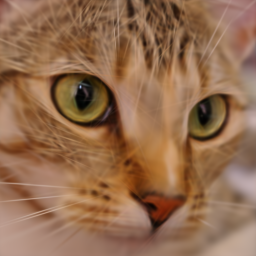

In [17]:
SAVE_IMAGE_AS = "cat_2048_no_densify.png"
save_img = img
Image.fromarray(save_img).save(SAVE_IMAGE_AS)
open_img = Image.open(SAVE_IMAGE_AS)
open_img

# Execution (3D)

In [7]:
import copy

class Camera:
    def __init__(self, image, R, t, K, H, W, file, xy):
        self.image = image # can be none
        self.R = R
        self.t = t
        self.K = K
        self.H = H
        self.W = W
        self.file = file
        self.xy = xy


with open("spheres/cameras.json", "r") as f:
    data = json.load(f)

H = data["height"]
W = data["width"]
K = torch.tensor(data["K"], dtype=torch.float32)

train_cameras = []
val_cameras = []



for frame in tqdm(data["frames"], desc="Loading training frames"):
    name = frame["file"]
    image = torch.from_numpy(
        np.array(Image.open(f"spheres/{name}").convert("RGB"))
    ).float().to(device) / 255.0

    R = torch.tensor(frame["R_wc"], dtype=torch.float32, device=device)
    t = torch.tensor(frame["t"], dtype=torch.float32, device=device)
    H, W, _ = image.shape
    xy = GaussianSplat2D.pixel_grid(H, W, device)

    train_cameras.append(Camera(image, R, t, K, H, W, name, xy))

for frame in tqdm(data["val_frames"], desc="Loading validation frames"):
    name = frame["file"]
    R = torch.tensor(frame["R_wc"], dtype=torch.float32, device=device)
    t = torch.tensor(frame["t"], dtype=torch.float32, device=device)
    K = torch.tensor(data["K"], dtype=torch.float32, device=device)
    image = torch.from_numpy(
        np.array(Image.open(f"spheres/{name}").convert("RGB"))
    ).float().to(device) / 255.0
    H, W, _ = image.shape
    xy = GaussianSplat2D.pixel_grid(H, W, device)

    val_cameras.append(Camera(image, R, t, K, H, W, name, xy))

new_camera = copy.deepcopy(val_cameras[0])
new_camera.image = None
new_camera.t = torch.tensor([0.0, 0.0, 10.0], dtype=torch.float32, device=device)
new_camera.name = "novel/000.png"
val_cameras.append(new_camera)



Loading training frames:   0%|          | 0/44 [00:00<?, ?it/s]

Loading validation frames:   0%|          | 0/12 [00:00<?, ?it/s]

In [13]:
N = 4096
budget = 4098
final_imgs = GaussianSplat3D.optimize3D(train_cameras, val_cameras, N, budget, densify=False)


Processing items:   0%|          | 0/1500 [00:00<?, ?it/s]

File: train/000.png | PSNR: 21.94 dB
File: train/001.png | PSNR: 23.07 dB
File: train/002.png | PSNR: 22.20 dB
File: train/003.png | PSNR: 22.29 dB
File: train/004.png | PSNR: 20.58 dB
File: train/005.png | PSNR: 21.47 dB
File: train/006.png | PSNR: 23.42 dB
File: train/007.png | PSNR: 20.83 dB
File: train/008.png | PSNR: 24.30 dB
File: train/009.png | PSNR: 22.73 dB
File: train/010.png | PSNR: 23.56 dB
File: train/011.png | PSNR: 23.38 dB
File: train/012.png | PSNR: 24.63 dB
File: train/013.png | PSNR: 22.83 dB
File: train/014.png | PSNR: 22.85 dB
File: train/015.png | PSNR: 22.86 dB
File: train/016.png | PSNR: 24.69 dB
File: train/017.png | PSNR: 24.31 dB
File: train/018.png | PSNR: 24.78 dB
File: train/019.png | PSNR: 24.14 dB
File: train/020.png | PSNR: 23.45 dB
File: train/021.png | PSNR: 22.93 dB
File: train/022.png | PSNR: 23.04 dB
File: train/023.png | PSNR: 24.22 dB
File: train/024.png | PSNR: 24.91 dB
File: train/025.png | PSNR: 21.43 dB
File: train/026.png | PSNR: 26.00 dB
F

In [14]:
sample = None
for res in final_imgs:
    image, file = res
    filename = file.split("/")[-1]
    dataset = file.split("/")[0]
    number = filename.split(".")[0]
    viewpoint = f"{dataset}_{int(number)}"
    sample = f"Results/gs_{N}_{budget}_{viewpoint}.png"
    Image.fromarray(image).save(f"Results/gs_{N}_{budget}_{viewpoint}.png")

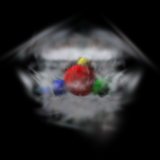

In [15]:
open_img = Image.open(sample)
open_img